In [362]:
import sys
from pathlib import Path

sys.path.append(str(Path("..").resolve()))

import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import matplotlib.dates as mdates
from pandas.plotting import scatter_matrix
import seaborn as sns
from src.features.feature_utils import baseline_df_transformer

from sklearn.decomposition import PCA
from sklearn.linear_model import LinearRegression
from sklearn.metrics import root_mean_squared_error

from statsmodels.graphics.tsaplots import plot_acf

In [299]:
# Load Train dataset.
TRAIN_LOAD_LOCATION = '../data/raw/train.xlsx'

df = pd.read_excel(TRAIN_LOAD_LOCATION)

In [301]:
df.head()

,Year,Month,Day,Hour,Load,Site-1 Temp,Site-2 Temp,Site-3 Temp,Site-4 Temp,Site-5 Temp,Site-1 GHI,Site-2 GHI,Site-3 GHI,Site-4 GHI,Site-5 GHI
0,1,1,1,1,1997,8.0,8.2,5.3,9.4,8.1,0,0,0,0,0
1,1,1,1,2,1921,8.3,8.6,5.2,8.6,7.1,0,0,0,0,0
2,1,1,1,3,1861,8.1,8.8,5.1,8.7,6.2,0,0,0,0,0
3,1,1,1,4,1833,7.6,8.1,4.3,8.5,6.0,0,0,0,0,0
4,1,1,1,5,1847,7.3,7.5,4.0,8.6,6.9,0,0,0,0,0


In [303]:
def df_transformer(df):

    YEARS_DICT = {1:2020, 2:2021, 3:2022}

    TEMP_COLS = [f"Site-{i + 1} Temp" for i in range(5)]
    GHI_COLS = [f"Site-{i + 1} GHI" for i in range(5)]

    df_transformed = df.copy()
    
    # Transform temperature readings to Farenheit.
    df_transformed[TEMP_COLS] = df_transformed[TEMP_COLS].apply(lambda x: x * 9/5 + 32)
    
    # Average the temperature and GHI measurements across all sites, to explore temperature effects simply.
    df_transformed["avg_region_temp"] = df_transformed[TEMP_COLS].mean(axis=1)
    df_transformed["avg_region_ghi"] = df_transformed[GHI_COLS].mean(axis=1)
    
    # Create timestamps.
    df_transformed['Year'] = df_transformed['Year'].map(YEARS_DICT)
    df_transformed['Hour'] = df_transformed['Hour'] - 1
    df_transformed['timestamp'] = pd.to_datetime(df_transformed[['Year', 'Month', 'Day', 'Hour']])

    # Ensure chronological ordering.
    df_transformed = df_transformed.sort_values("timestamp")

    # Add feature indicating weekend.
    df_transformed['is_weekend'] = (df_transformed['timestamp'].dt.weekday >= 5).astype(int)

    # Rearrange columns

    cols = list(df_transformed.columns)
    cols.remove("timestamp")
    df_transformed = df_transformed[["timestamp"] + cols]

    return df_transformed

In [305]:
df = df_transformer(df)
df.head()

,timestamp,Year,Month,Day,Hour,Load,Site-1 Temp,Site-2 Temp,Site-3 Temp,Site-4 Temp,Site-5 Temp,Site-1 GHI,Site-2 GHI,Site-3 GHI,Site-4 GHI,Site-5 GHI,avg_region_temp,avg_region_ghi,is_weekend
0,2020-01-01 00:00:00,2020,1,1,0,1997,46.40,46.76,41.54,48.92,46.58,0,0,0,0,0,46.040,0.0,0
1,2020-01-01 01:00:00,2020,1,1,1,1921,46.94,47.48,41.36,47.48,44.78,0,0,0,0,0,45.608,0.0,0
2,2020-01-01 02:00:00,2020,1,1,2,1861,46.58,47.84,41.18,47.66,43.16,0,0,0,0,0,45.284,0.0,0
3,2020-01-01 03:00:00,2020,1,1,3,1833,45.68,46.58,39.74,47.30,42.80,0,0,0,0,0,44.420,0.0,0
4,2020-01-01 04:00:00,2020,1,1,4,1847,45.14,45.50,39.20,47.48,44.42,0,0,0,0,0,44.348,0.0,0


In [307]:
def cyclic_month_day_transformer(df):
    df_transformed = df.copy()
    
    df_transformed["Hour_sin"] = np.sin(2*np.pi*df_transformed["Hour"]/24)
    df_transformed["Hour_cos"] = np.cos(2*np.pi*df_transformed["Hour"]/24)
    
    df_transformed["Month_sin"] = np.sin(2*np.pi*df_transformed["Month"]/24)
    df_transformed["Month_cos"] = np.cos(2*np.pi*df_transformed["Month"]/24)

    return df_transformed

In [309]:
df = cyclic_month_day_transformer(df)

/var/folders/x5/mt3y0q2n65zcpd0hz503pkx00000gn/T/ipykernel_77119/3442187308.py:5: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  binned_stats = load_temp_df.groupby("temp_bin")["Load"].agg(["mean", "std"]).reset_index()


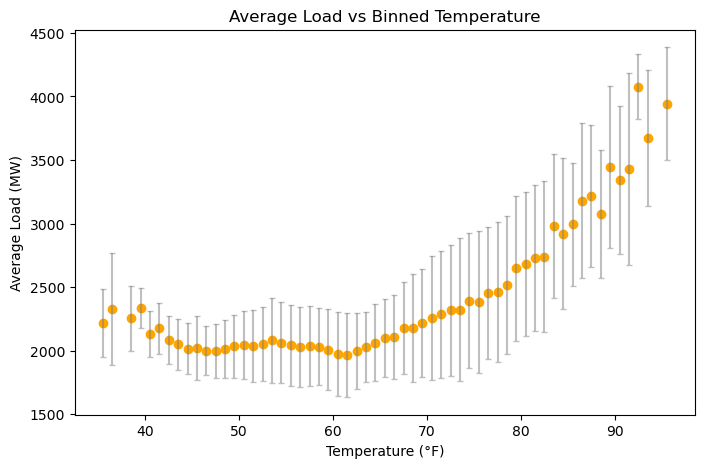

In [311]:
load_temp_df = df[["Load", "avg_region_temp"]].copy()

load_temp_df["temp_bin"] = pd.cut(load_temp_df["avg_region_temp"], bins=range(int(load_temp_df["avg_region_temp"].min()), int(load_temp_df["avg_region_temp"].max())+1, 1))

binned_stats = load_temp_df.groupby("temp_bin")["Load"].agg(["mean", "std"]).reset_index()
binned_stats["temp_mid"] = binned_stats["temp_bin"].apply(lambda x: x.mid)

plt.figure(figsize=(8,5))
plt.scatter(binned_stats["temp_mid"], binned_stats["mean"], color = "orange")

plt.errorbar(
    binned_stats["temp_mid"], 
    binned_stats["mean"], 
    yerr=binned_stats["std"], 
    fmt="none",
    ecolor="gray",
    alpha=0.5,
    capsize=2
)

plt.xlabel("Temperature (°F)")
plt.ylabel("Average Load (MW)")
plt.title("Average Load vs Binned Temperature")
plt.show()


Eveidence of a relationship between temperature and load, but it is nonlinear globally, but has linear trends at higher and lower temperatures. In order to isolate the tails, I define use heating and cooling degree hour features. These features are defined as

$$ \text{HDH} = max(0,\; T_b - T) $$
$$ \text{CDH} = max(0,\; T - T_b), $$

where T is the temperature and T_b is a base temperature, meant to represent a normal comfortable temperature for humans.

In [314]:
base_t = 60

load_temp_df["CDH"] = (load_temp_df["avg_region_temp"] - base_t).clip(lower=0)
load_temp_df["HDH"] = (base_t - load_temp_df["avg_region_temp"]).clip(lower=0)

/var/folders/x5/mt3y0q2n65zcpd0hz503pkx00000gn/T/ipykernel_77119/2086800347.py:6: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  binned_CDH = load_temp_df.groupby("CDH_bin")["Load"].agg(["mean", "std"]).reset_index()
/var/folders/x5/mt3y0q2n65zcpd0hz503pkx00000gn/T/ipykernel_77119/2086800347.py:9: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  binned_HDH = load_temp_df.groupby("HDH_bin")["Load"].agg(["mean", "std"]).reset_index()


Text(0.5, 1.0, 'Average Load vs Binned Temperature')

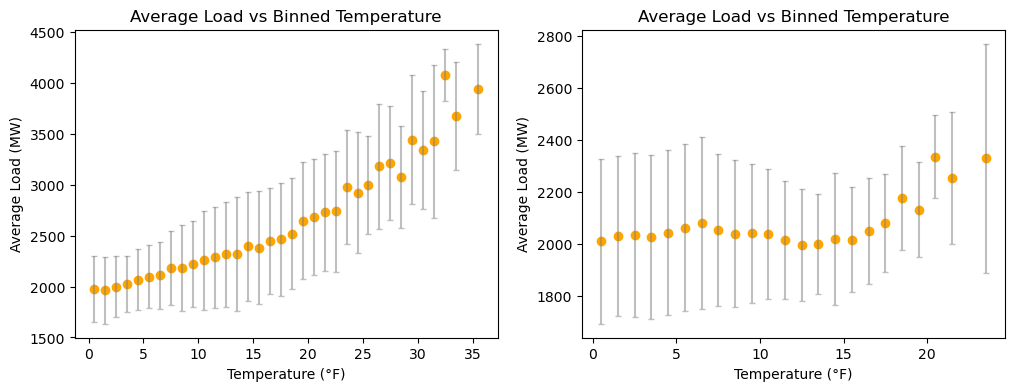

In [316]:
fig, ax = plt.subplots(1, 2, figsize = (12, 4))

load_temp_df["CDH_bin"] = pd.cut(load_temp_df["CDH"], bins=range(0, int(load_temp_df["CDH"].max())+1, 1))
load_temp_df["HDH_bin"] = pd.cut(load_temp_df["HDH"], bins=range(0, int(load_temp_df["HDH"].max())+1, 1))

binned_CDH = load_temp_df.groupby("CDH_bin")["Load"].agg(["mean", "std"]).reset_index()
binned_CDH["CDH_mid"] = binned_CDH["CDH_bin"].apply(lambda x: x.mid)

binned_HDH = load_temp_df.groupby("HDH_bin")["Load"].agg(["mean", "std"]).reset_index()
binned_HDH["HDH_mid"] = binned_HDH["HDH_bin"].apply(lambda x: x.mid)

ax[0].scatter(binned_CDH["CDH_mid"], binned_CDH["mean"], color = "orange")
ax[1].scatter(binned_HDH["HDH_mid"], binned_HDH["mean"], color = "orange")

ax[0].errorbar(
    binned_CDH["CDH_mid"], 
    binned_CDH["mean"], 
    yerr=binned_CDH["std"], 
    fmt="none",
    ecolor="gray",
    alpha=0.5,
    capsize=2
)
ax[1].errorbar(
    binned_HDH["HDH_mid"], 
    binned_HDH["mean"], 
    yerr=binned_HDH["std"], 
    fmt="none",
    ecolor="gray",
    alpha=0.5,
    capsize=2
)

ax[0].set_xlabel("Temperature (°F)")
ax[0].set_ylabel("Average Load (MW)")
ax[0].set_title("Average Load vs Binned Temperature")

ax[1].set_xlabel("Temperature (°F)")
ax[1].set_ylabel("Average Load (MW)")
ax[1].set_title("Average Load vs Binned Temperature")


In [318]:
load_temp_df = load_temp_df[["Load", "avg_region_temp", "CDH", "HDH"]]

Thermal intertia is also important to consider, as buildings heat up/cool down over time. A/C and heat usage is not instantaneous response to temperature, but builds up over time. As such, it is important to consider temperature features over some window of time.

In [321]:
# Average of the temperature for the last 3, 6, and 24 hours.
load_temp_df["temp_3h"] = load_temp_df["avg_region_temp"].rolling(3).mean()
load_temp_df["temp_6h"] = load_temp_df["avg_region_temp"].rolling(6).mean()
load_temp_df["temp_24h"] = load_temp_df["avg_region_temp"].rolling(24).mean()

# Aggregate of the Cooling Degree Hours for the last 3, 6, and 24 hours.
load_temp_df["CDH_3h"] = load_temp_df["CDH"].rolling(3).sum()
load_temp_df["CDH_6h"] = load_temp_df["CDH"].rolling(6).sum()
load_temp_df["CDH_24h"] = load_temp_df["CDH"].rolling(24).sum()

# Aggregate of the Heating Degree Hours for the last 3, 6, and 24 hours.
load_temp_df["HDH_3h"] = load_temp_df["HDH"].rolling(3).sum()
load_temp_df["HDH_6h"] = load_temp_df["HDH"].rolling(6).sum()
load_temp_df["HDH_24h"] = load_temp_df["HDH"].rolling(24).sum()

In [323]:
load_temp_df.corr()

,Load,avg_region_temp,CDH,HDH,temp_3h,temp_6h,temp_24h,CDH_3h,CDH_6h,CDH_24h,HDH_3h,HDH_6h,HDH_24h
Load,1.000000,0.405158,0.473036,-0.153479,0.480336,0.579828,0.424500,0.558012,0.664147,0.504696,-0.190533,-0.256659,-0.203491
avg_region_temp,0.405158,1.000000,0.928309,-0.780801,0.982503,0.915785,0.791142,0.915741,0.862566,0.765736,-0.771126,-0.722269,-0.687010
CDH,0.473036,0.928309,1.000000,-0.492526,0.911146,0.839806,0.722888,0.978835,0.898353,0.752149,-0.496057,-0.479830,-0.535384
HDH,-0.153479,-0.780801,-0.492526,1.000000,-0.768676,-0.732419,-0.637209,-0.498564,-0.509232,-0.528364,0.971579,0.884741,0.708888
temp_3h,0.480336,0.982503,0.911146,-0.768676,1.000000,0.968617,0.803689,0.930932,0.910515,0.777606,-0.786747,-0.767018,-0.698388
temp_6h,0.579828,0.915785,0.839806,-0.732419,0.968617,1.000000,0.833222,0.895688,0.935516,0.805660,-0.772265,-0.799519,-0.724968
temp_24h,0.424500,0.791142,0.722888,-0.637209,0.803689,0.833222,1.000000,0.736029,0.768201,0.962344,-0.652953,-0.685484,-0.878132
CDH_3h,0.558012,0.915741,0.978835,-0.498564,0.930932,0.895688,0.736029,1.000000,0.962006,0.766591,-0.506983,-0.505170,-0.543764
CDH_6h,0.664147,0.862566,0.898353,-0.509232,0.910515,0.935516,0.768201,0.962006,1.000000,0.800765,-0.522867,-0.535766,-0.566361
CDH_24h,0.504696,0.765736,0.752149,-0.528364,0.777606,0.805660,0.962344,0.766591,0.800765,1.000000,-0.539539,-0.564091,-0.715015


From the correlation matrix above, it is clear that aggregating temperature stats over the last 6 hours increases correlation with load, as is evident by the temp_6h x Load correlation (0.57), and the CDH_6h x Load correlation (0.66).

Furthermore, cooling degree hours show a higher correlation than heating degree hours. This aligns with the fact that San Diego is hotter on average.

As all these features are transformations on temperature, they are highly correlated with one another. Including all these features risks poor model performance due to multicollinearity.

## To address this, I will select the following features for the model: region temperature, 6-hour rolling average temperature, 6-hour aggregated heating degree hours, and 6-hour aggregated cooling degree hours. Given their high intercorrelation, I will apply PCA to reduce these features into a lower-dimensional representation while retaining most of the information.

In [ ]:
df = df.merge(load_temp_df, on = ["Load", "avg_region_temp"])
df = df.dropna()

In [426]:
pca = PCA(n_components = 3)

pca_features = ["avg_region_ghi", "avg_region_temp", "temp_3h", "temp_6h", "temp_24h", "CDH", "CDH_3h", "CDH_6h", "CDH_24h", "HDH", "HDH_3h", "HDH_6h", "HDH_24h"]
X = df[pca_features]

pca.fit(X)
X_pca = pd.DataFrame(pca.transform(X), columns=["PC1", "PC2", "PC3"],  index = X.index)

In [428]:
df_with_pca = pd.concat([df, X_pca], axis=1)

# Check result
df_with_pca.head()

,timestamp,Year,Month,Day,Hour,Load,Site-1 Temp,Site-2 Temp,Site-3 Temp,Site-4 Temp,...,temp_24h,CDH_3h,CDH_6h,CDH_24h,HDH_3h,HDH_6h,HDH_24h,PC1,PC2,PC3
23,2020-01-01 23:00:00,2020,1,1,23,1923,53.42,53.24,52.16,53.24,...,52.9145,0.0,0.0,9.804,20.496,37.752,179.856,-240.325061,-146.577946,58.397182
24,2020-01-02 00:00:00,2020,1,2,0,1849,52.88,52.52,50.54,52.52,...,53.1500,0.0,0.0,9.804,22.476,40.920,174.204,-240.218487,-144.806078,54.489579
25,2020-01-02 01:00:00,2020,1,2,1,1812,51.98,52.16,48.92,52.16,...,53.3705,0.0,0.0,9.804,24.888,44.160,168.912,-240.136531,-143.212838,50.958835
26,2020-01-02 02:00:00,2020,1,2,2,1801,50.36,51.62,48.56,50.90,...,53.5580,0.0,0.0,9.804,27.624,48.120,164.412,-240.118666,-142.058232,48.333360
27,2020-01-02 03:00:00,2020,1,2,3,1772,49.10,50.54,47.12,49.46,...,53.7260,0.0,0.0,9.804,30.864,53.340,160.380,-240.164123,-141.273839,46.471539


In [372]:
splits_df_loc = "../data/splits/split_bounds.csv"
splits_df = pd.read_csv(splits_df_loc)

def linear_rmse_on_features(df, features_to_train):

    print("Now training on: ", features_to_train)

    rmse_list = []

    for i in range(1, 6):
        split = f"split_{i}"
    
        row = splits_df[splits_df["split"] == split].iloc[0]
        train_start_date = row["train_start_date"]
        train_end_date = row["train_end_date"]
        val_start_date = row["val_start_date"]
        val_end_date = row["val_end_date"]
    
        train_mask = (df["timestamp"] >= train_start_date) & (df["timestamp"] < train_end_date)
        val_mask = (df["timestamp"] >= val_start_date) & (df["timestamp"] < val_end_date)
        
        train_split = df[train_mask]
        val_split = df[val_mask]
    
        X_train = train_split[features_to_train]
        y_train = train_split["Load"]
    
        X_val = val_split[features_to_train]
        y_val = val_split["Load"]
    
        model = LinearRegression()
        model.fit(X_train, y_train)
    
        y_pred = model.predict(X_val)
        rmse = root_mean_squared_error(y_val, y_pred)
    
        rmse_list.append(rmse)
    print("RMSEs: ", rmse_list)
    print(f"Average RMSE across splits: {np.mean(rmse_list):.2f} ± {np.std(rmse_list):.2f}\n")

In [374]:
df.columns

Index(['timestamp', 'Year', 'Month', 'Day', 'Hour', 'Load', 'Site-1 Temp',
       'Site-2 Temp', 'Site-3 Temp', 'Site-4 Temp', 'Site-5 Temp',
       'Site-1 GHI', 'Site-2 GHI', 'Site-3 GHI', 'Site-4 GHI', 'Site-5 GHI',
       'avg_region_temp', 'avg_region_ghi', 'is_weekend', 'Hour_sin',
       'Hour_cos', 'Month_sin', 'Month_cos', 'CDH', 'HDH', 'temp_3h',
       'temp_6h', 'temp_24h', 'CDH_3h', 'CDH_6h', 'CDH_24h', 'HDH_3h',
       'HDH_6h', 'HDH_24h'],
      dtype='object')

In [380]:
linear_rmse_on_features(df = df, features_to_train = ["avg_region_temp", "Month_sin", "Month_cos", "Hour_sin", "Hour_cos", "CDH", "HDH"])
linear_rmse_on_features(df = df, features_to_train = ["avg_region_temp", "is_weekend", "CDH", "HDH"])
linear_rmse_on_features(df = df, features_to_train = ["avg_region_temp", "Month", "Hour_sin", "Hour_cos", "CDH", "HDH"])
linear_rmse_on_features(df = df, features_to_train = ["avg_region_temp", "Month_sin", "Month_cos", "Hour_sin", "Hour_cos", "CDH", "HDH"])

Now training on:  ['avg_region_temp', 'Month_sin', 'Month_cos', 'Hour_sin', 'Hour_cos', 'CDH', 'HDH']
RMSEs:  [817.076375159451, 306.82082496019535, 326.0625087613377, 339.15805412678566, 334.3682157435894]
Average RMSE across splits: 424.70 ± 196.50

Now training on:  ['avg_region_temp', 'is_weekend', 'CDH', 'HDH']
RMSEs:  [377.25928766177674, 348.0593182791381, 379.2190903121359, 398.2586960285346, 366.59498321403555]
Average RMSE across splits: 373.88 ± 16.46

Now training on:  ['avg_region_temp', 'Month', 'Hour_sin', 'Hour_cos', 'CDH', 'HDH']
RMSEs:  [392.7208197197843, 306.17900604940274, 333.88087961471405, 338.15497032186903, 321.69811804701123]
Average RMSE across splits: 338.53 ± 29.29

Now training on:  ['avg_region_temp', 'Month_sin', 'Month_cos', 'Hour_sin', 'Hour_cos', 'CDH', 'HDH']
RMSEs:  [817.076375159451, 306.82082496019535, 326.0625087613377, 339.15805412678566, 334.3682157435894]
Average RMSE across splits: 424.70 ± 196.50



In [448]:
linear_rmse_on_features(df = df, features_to_train = ["temp_6h", "Month", "Hour_sin", "Hour_cos", "CDH", "HDH", "avg_region_ghi"])
linear_rmse_on_features(df = df, features_to_train = ["temp_6h", "Month", "Hour_sin", "Hour_cos", "CDH", "HDH", "avg_region_ghi", "is_weekend"])
linear_rmse_on_features(df = df, features_to_train = ["avg_region_temp", "Month", "Hour_sin", "Hour_cos", "CDH_6h", "HDH_6h", "avg_region_ghi", "is_weekend"])
linear_rmse_on_features(df = df, features_to_train = ["avg_region_temp", "temp_24h", "Month", "Hour_sin", "Hour_cos", "CDH_6h", "HDH_6h", "avg_region_ghi", "is_weekend"])
linear_rmse_on_features(df = df, features_to_train = ["temp_6h", "Month", "Hour_sin", "Hour_cos", "CDH_6h", "HDH_6h", "avg_region_ghi", "is_weekend"])

linear_rmse_on_features(df = df_with_pca, features_to_train = ["PC1", "PC2", "PC3", "Month", "Hour_sin", "Hour_cos", "is_weekend"])


Now training on:  ['temp_6h', 'Month', 'Hour_sin', 'Hour_cos', 'CDH', 'HDH', 'avg_region_ghi']
RMSEs:  [255.15563804738738, 207.97688351628452, 169.34539597146764, 241.95952890924815, 281.7128127195763]
Average RMSE across splits: 231.23 ± 39.00

Now training on:  ['temp_6h', 'Month', 'Hour_sin', 'Hour_cos', 'CDH', 'HDH', 'avg_region_ghi', 'is_weekend']
RMSEs:  [244.66990699256462, 191.92709744469207, 153.5779845379108, 220.6293465196674, 266.41536325948937]
Average RMSE across splits: 215.44 ± 39.65

Now training on:  ['avg_region_temp', 'Month', 'Hour_sin', 'Hour_cos', 'CDH_6h', 'HDH_6h', 'avg_region_ghi', 'is_weekend']
RMSEs:  [246.70379035233032, 204.98320668725702, 157.64436438018183, 235.76128515080518, 265.1811928736715]
Average RMSE across splits: 222.05 ± 37.67

Now training on:  ['avg_region_temp', 'temp_24h', 'Month', 'Hour_sin', 'Hour_cos', 'CDH_6h', 'HDH_6h', 'avg_region_ghi', 'is_weekend']
RMSEs:  [249.63282682569735, 203.36601338705952, 156.62159505161557, 233.7292511719